In [20]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION + ROBUST FEATURE DISCOVERY PIPELINE (PRODUCTION)
===================================================================

Goal:
  - Reconstruct AMOC with as few interpretable features as possible
  - Choose hyperparameters using time-series CV inside train (no test leakage)
  - Identify "robust" predictors via stability selection across members
  - Optionally compute early-warning metrics (lag-1 AC, variance) on selected PCs

Supports:
  ✅ Any model with:
      - EOF_latdepth_<var>_<lon>.nc containing PC(member?, time, mode)
      - AMOC_<MODEL>.nc containing AMOC_26N_* and/or AMOC_45N_* (ensmean and member)
  ✅ Run on ensemble-mean OR member-by-member (choose)
  ✅ Final test block is last 20% of years (blocked, never used in CV/ranking)

Key design choices (thesis-defensible):
  - Feature ranking (corr across lags) is done ONLY on fold-train (inside CV)
  - Hyperparameters (N_seeds, W, alpha) chosen by mean CV validation R²
  - "Parsimonious model": choose smallest within 1σ of best CV score (optional)
  - Stability selection: keep only features appearing in ≥freq threshold across members

Outputs (in OUTDIR/<MODEL>/<TARGET>/):
  - cv_grid_results_*.csv
  - best_params_*.txt
  - best_features_*.csv
  - (member mode) member_best_features_*.csv, stability_features_*.csv
  - final_test_metrics_*.csv, final_test_predictions_*.csv
  - (optional) ews_metrics_*.csv
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt


In [21]:
# =========================
# USER CONFIG
# =========================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"     # e.g. "AMOC_45N_ensmean" or "AMOC_45N_member"
MODE   = "ensmean"              # "ensmean" or "member"

# If MODE=="member", choose which members to run:
MEMBERS = [0, 1, 2, 3, 4]        # start small to test

CFG = dict(
    # paths
    EOF_DIR_TEMPLATE="/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/",
    AMOC_FILE_TEMPLATE="/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc",
    OUT_ROOT="/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/",

    # time range + splits
    YEAR_START=1850,
    YEAR_END=2014,
    TEST_FRAC=0.20,              # final test = last 20%
    N_SPLITS=5,                  # TimeSeriesSplit folds inside trainval
    GAP_EMBARGO=10,              # IMPORTANT: should be <= MAX_LAG_ALLOWED

    # predictor space
    VARS=["thetao", "so"],
    LON_TAGS=["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"],
    N_MODES=10,

    # lag settings
    MAX_LAG_TOTAL=50,            # total lags considered in ranking
    MAX_LAG_ALLOWED=20,          # restrict to <= this in ranking + feature building
    CAP_LAGS_PER_GROUP=None,     # e.g. 5 or None

    # hyperparameter grids (start small)
    N_LIST=[5, 10, 15],
    W_LIST=[0, 1],
    RIDGE_ALPHAS=[1, 10, 100, 1000, 1e4],

    # parsimony (recommended)
    USE_ONE_SE_RULE=True,
)

# output folder for this run
OUTDIR = os.path.join(CFG["OUT_ROOT"], MODEL, TARGET, f"mode_{MODE}")
os.makedirs(OUTDIR, exist_ok=True)
print("OUTDIR:", OUTDIR)


OUTDIR: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean


#### Low-level helpers (loading + years + correlation) and Core pipeline functions (CV with fold-train ranking + final test)

In [22]:

# -------------------------
# Helpers
# -------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    """
    Feature-building PC loader.
    Returns PC as (year, mode). If member exists:
      - member_mode=False -> mean over member
      - member_mode=True  -> select member_id
    """
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            # allow either label or index
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.data_vars:
        raise KeyError(f"Target '{target}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year  # (year,)

def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank):
    """
    Rank by |corr| using ONLY the provided subset (fold-train).
    pc_np_sub: dict[(var,lon)] -> np.ndarray (Tsub, n_modes)
    y_sub: np.ndarray (Tsub,)
    """
    rows = []
    Tsub = len(y_sub)

    for var in vars_:
        for lon in lons_:
            if (var, lon) not in pc_np_sub:
                continue
            pc = pc_np_sub[(var, lon)]  # (Tsub, n_modes)

            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_sub[t_idx]

                for m in range(int(n_modes)):
                    pp = pc[p_idx, m]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var, "lon": lon, "mode": int(m+1),
                            "lag": int(lag), "corr": float(c), "abs_corr": float(abs(c))
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)

def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    df_top = df_ranked.head(int(n_seeds))
    seeds = [(str(r.var), str(r.lon), int(r.mode)-1, int(r.lag)) for r in df_top.itertuples(index=False)]

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(int(lag0) - int(W), int(lag0) + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, int(m0), int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var, lon, mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_XY(pc_np_full, y_full, feats, t_positions):
    """
    pc_np_full: dict[(var,lon)] -> np.ndarray (T, n_modes)
    y_full: np.ndarray (T,)
    feats: list[(var, lon, mode0, lag)]
    t_positions: indices into FULL time axis (0..T-1)
    """
    t_positions = np.asarray(t_positions, dtype=int)
    max_lag = max((lag for (_, _, _, lag) in feats), default=0)

    used = t_positions[t_positions >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), dtype=float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, int(m0)]
    Y = y_full[used]
    return X, Y, used, int(max_lag)

def make_gap_folds(T_trainval, n_splits, gap, max_lag_allowed, min_corr_points=30):
    base = np.arange(T_trainval, dtype=int)
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []
    for tr, va in tscv.split(base):
        if gap is not None and gap > 0:
            if len(tr) <= gap:
                continue
            tr = tr[:-int(gap)]

        if max_lag_allowed is not None:
            if len(tr) - int(max_lag_allowed) < int(min_corr_points):
                continue

        if len(tr) < 20 or len(va) < 10:
            continue

        folds.append((tr, va))
    return folds

def one_se_rule_choose(df_grid):
    best = df_grid.iloc[0]
    threshold = best["mean_val_r2"] - best["std_val_r2"]
    ok = df_grid[df_grid["mean_val_r2"] >= threshold].copy()
    if len(ok) == 0:
        return best.to_dict()
    ok = ok.sort_values(["N_seeds", "W", "alpha"], ascending=[True, True, False]).reset_index(drop=True)
    return ok.iloc[0].to_dict()

def run_pipeline_one(model, target, mode, cfg, member_id=None, outdir=None, verbose=True):
    EOF_DIR = cfg["EOF_DIR_TEMPLATE"].format(MODEL=model)
    AMOC_FILE = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # ----- Load PCs for ALL configured (var, lon) pairs -----
    pc_dict = {}
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            pc_dict[(var, lon)] = load_pc(
                EOF_DIR, var, lon, cfg["N_MODES"],
                member_mode=(mode == "member"),
                member_id=member_id
            )

    # ----- Load AMOC -----
    am = load_amoc(AMOC_FILE, target, member_mode=(mode == "member"), member_id=member_id)

    # ----- Align years -----
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= cfg["YEAR_START"]) & (common_years <= cfg["YEAR_END"])]

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

    T = len(common_years)
    n_test = int(np.ceil(cfg["TEST_FRAC"] * T))
    n_trainval = T - n_test

    idx_trainval = np.arange(0, n_trainval, dtype=int)
    idx_test     = np.arange(n_trainval, T, dtype=int)

    if verbose:
        print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={T})")
        print(f"✓ TRAINVAL (80%): {common_years[0]}–{common_years[n_trainval-1]} (T={n_trainval})")
        print(f"✓ TEST (20%):     {common_years[n_trainval]}–{common_years[-1]} (T={len(idx_test)})")

    # lags used in ranking (restricted)
    lags = np.arange(0, int(cfg["MAX_LAG_TOTAL"]), dtype=int)
    if cfg["MAX_LAG_ALLOWED"] is not None:
        lags = lags[lags <= int(cfg["MAX_LAG_ALLOWED"])]

    folds = make_gap_folds(
        len(idx_trainval),
        cfg["N_SPLITS"],
        cfg["GAP_EMBARGO"],
        cfg["MAX_LAG_ALLOWED"],
        min_corr_points=30
    )

    if verbose:
        print("FOLDS USED:", len(folds))
        for i, (tr, va) in enumerate(folds):
            print(i, "train:", len(tr), "val:", len(va))
        print("\nRunning TimeSeriesSplit CV on TRAINVAL...")

    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                r2s, cors, vrs = [], [], []
                nfeats_list, maxlags = [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_trainval[tr_rel]
                    va_idx = idx_trainval[va_rel]

                    y_tr = y_full[tr_idx]
                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :]
                             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

                    df_rank_fold = rank_features_train_only(
                        pc_tr, y_tr, cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags
                    )

                    feats = build_feature_set(
                        df_rank_fold,
                        n_seeds=N_seeds,
                        W=W,
                        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
                        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
                    )

                    Xtr, Ytr, _, maxlag = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _      = build_XY(pc_np_full, y_full, feats, va_idx)

                    if len(Ytr) < 20 or len(Yva) < 10:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)
                    pred = mdl.predict(Xva)

                    r2, r, vr = metrics(Yva, pred)
                    r2s.append(r2); cors.append(r); vrs.append(vr)
                    nfeats_list.append(len(feats)); maxlags.append(maxlag)

                if len(r2s) < max(2, len(folds) - 1):
                    continue

                mean_r2 = float(np.mean(r2s))
                std_r2  = float(np.std(r2s))

                if verbose:
                    print(f"  N={int(N_seeds):2d} W={int(W)} alpha={alpha:<7g} | val R²={mean_r2: .4f} ±{std_r2:.4f} (folds={len(r2s)})")

                grid_rows.append({
                    "N_seeds": int(N_seeds),
                    "W": int(W),
                    "alpha": float(alpha),
                    "mean_val_r2": mean_r2,
                    "std_val_r2": std_r2,
                    "mean_val_corr": float(np.mean(cors)),
                    "mean_val_var_ratio": float(np.mean(vrs)),
                    "mean_n_features": float(np.mean(nfeats_list)),
                    "mean_max_lag": float(np.mean(maxlags)),
                    "n_folds_used": int(len(r2s)),
                })

    df_grid = pd.DataFrame(grid_rows).sort_values(["mean_val_r2", "std_val_r2"], ascending=[False, True]).reset_index(drop=True)
    if len(df_grid) == 0:
        raise RuntimeError("No CV results produced. Reduce gap, reduce lags, or loosen grids.")

    best = one_se_rule_choose(df_grid) if cfg["USE_ONE_SE_RULE"] else df_grid.iloc[0].to_dict()

    # ----- Final ranking on FULL trainval only -----
    y_tv = y_full[idx_trainval]
    pc_tv = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :]
             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

    df_rank_tv = rank_features_train_only(pc_tv, y_tv, cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags)

    # optional: save ranking
    if outdir is not None:
        rank_file = os.path.join(
            outdir,
            f"trainval_feature_ranking_{model}_{target}" + (f"_member{member_id}" if member_id is not None else "") + ".csv"
        )
        df_rank_tv.to_csv(rank_file, index=False)
        if verbose:
            print("✅ Saved trainval ranking to:", rank_file)

    feats_final = build_feature_set(
        df_rank_tv,
        n_seeds=int(best["N_seeds"]),
        W=int(best["W"]),
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
    )

    # ----- Fit final on trainval -----
    Xtv, Ytv, used_tv, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_trainval)
    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(Xtv, Ytv)

    # ----- Test once -----
    Xte, Yte, used_te, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    pred_te = final_model.predict(Xte)
    test_r2, test_corr, test_var = metrics(Yte, pred_te)

    out = dict(
        df_grid=df_grid,
        best=best,
        df_rank_tv=df_rank_tv,
        feats_final=feats_final,
        years=common_years,
        trainval_years=common_years[:n_trainval],
        test_years=common_years[n_trainval:],
        test_metrics=dict(
            test_r2=test_r2,
            test_corr=test_corr,
            test_var_ratio=test_var,
            max_lag_used=maxlag_final,
            n_features_used=len(feats_final),
        ),
        test_pred_df=pd.DataFrame({"year": common_years[used_te], "y_true": Yte, "y_pred": pred_te}),
        member_id=member_id,
    )
    return out


#### Run it (esmean or member)

In [23]:
if MODE == "ensmean":
    res = run_pipeline_one(MODEL, TARGET, "ensmean", CFG, member_id=None, outdir=OUTDIR, verbose=True)
    display(res["df_grid"].head(10))
    print("\nBEST:", res["best"])
    print("TEST:", res["test_metrics"])

    # ============================
    # ✅ SAVE BEST TEST RESULT HERE
    # ============================

    save_tag = f"R2_{res['test_metrics']['test_r2']:.3f}_N{int(res['best']['N_seeds'])}_W{int(res['best']['W'])}"

    # 1) Save test prediction timeseries (for plotting later)
    pred_file = os.path.join(OUTDIR, f"{save_tag}_test_predictions.csv")
    res["test_pred_df"].to_csv(pred_file, index=False)

    # 2) Save test metrics (R², corr, etc)
    metrics_file = os.path.join(OUTDIR, f"{save_tag}_test_metrics.csv")
    pd.DataFrame([res["test_metrics"]]).to_csv(metrics_file, index=False)

    # 3) Save best hyperparameters
    params_file = os.path.join(OUTDIR, f"{save_tag}_best_params.csv")
    pd.DataFrame([res["best"]]).to_csv(params_file, index=False)

    # 4) Save final selected feature list
    feat_file = os.path.join(OUTDIR, f"{save_tag}_final_features.csv")

    # 5) Save ranked features on trainval
    rank_file = os.path.join(OUTDIR, f"{save_tag}_trainval_feature_ranking.csv")
    res["df_rank_tv"].to_csv(rank_file, index=False)

    df_feats = pd.DataFrame([
        {"var": v, "lon": lon, "mode": m+1, "lag": lag}
        for (v, lon, m, lag) in res["feats_final"]
    ])

    df_feats.to_csv(feat_file, index=False)

    print("\n✅ Saved BEST run outputs:")
    print("Predictions:", pred_file)
    print("Metrics:     ", metrics_file)
    print("Params:      ", params_file)
    print("Features:    ", feat_file)
    print("Ranking:     ", rank_file)

else:
    member_results = []
    for mid in MEMBERS:
        print(f"\n===== MEMBER {mid} =====")
        try:
            r = run_pipeline_one(MODEL, TARGET, "member", CFG, member_id=mid, outdir=OUTDIR, verbose=True)
            member_results.append(r)
            print("BEST:", r["best"])
            print("TEST:", r["test_metrics"])
        except Exception as e:
            print(f"⚠️ member {mid} failed: {e}")

    print(f"\nMembers successful: {len(member_results)} / {len(MEMBERS)}")



✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL (80%): 1850–1981 (T=132)
✓ TEST (20%):     1982–2014 (T=33)
FOLDS USED: 3
0 train: 56 val: 22
1 train: 78 val: 22
2 train: 100 val: 22

Running TimeSeriesSplit CV on TRAINVAL...
  N= 5 W=0 alpha=1       | val R²=-1.7682 ±1.3509 (folds=3)
  N= 5 W=0 alpha=10      | val R²=-1.7362 ±1.3992 (folds=3)
  N= 5 W=0 alpha=100     | val R²=-1.4678 ±1.7258 (folds=3)
  N= 5 W=0 alpha=1000    | val R²=-1.7598 ±2.4893 (folds=3)
  N= 5 W=0 alpha=10000   | val R²=-2.0473 ±2.8442 (folds=3)
  N= 5 W=1 alpha=1       | val R²=-2.1016 ±1.3359 (folds=3)
  N= 5 W=1 alpha=10      | val R²=-1.7854 ±1.3666 (folds=3)
  N= 5 W=1 alpha=100     | val R²=-1.6703 ±1.9082 (folds=3)
  N= 5 W=1 alpha=1000    | val R²=-1.7893 ±2.5577 (folds=3)
  N= 5 W=1 alpha=10000   | val R²=-2.0451 ±2.8546 (folds=3)
  N=10 W=0 alpha=1       | val R²=-0.4261 ±0.4640 (folds=3)
  N=10 W=0 alpha=10      | val R²=-0.5483 ±0.5243 (folds=3)
  N=10 W=0 alpha=100     | val R²=-0.9377 ±0.7904 (folds=

,N_seeds,W,alpha,mean_val_r2,std_val_r2,mean_val_corr,mean_val_var_ratio,mean_n_features,mean_max_lag,n_folds_used
0,15,1,10.0,-0.052343,0.082736,0.213498,0.433277,27.333333,19.333333,3
1,15,0,10.0,-0.144766,0.047569,0.151960,0.416556,15.000000,19.000000,3
2,15,0,1.0,-0.409320,0.300519,0.111913,0.562318,15.000000,19.000000,3
3,10,0,1.0,-0.426058,0.463956,0.191913,0.438323,10.000000,18.666667,3
4,15,1,100.0,-0.479788,0.495502,0.241555,0.293576,27.333333,19.333333,3
5,10,0,10.0,-0.548316,0.524326,0.190823,0.350498,10.000000,18.666667,3
6,15,0,100.0,-0.789585,0.887774,0.196533,0.274528,15.000000,19.000000,3
7,10,1,100.0,-0.862693,0.512115,0.232928,0.272481,20.000000,19.000000,3
8,10,0,100.0,-0.937701,0.790438,0.148654,0.252652,10.000000,18.666667,3
9,10,1,10.0,-0.946560,1.130815,0.179911,0.386807,20.000000,19.000000,3



BEST: {'N_seeds': 15.0, 'W': 1.0, 'alpha': 10.0, 'mean_val_r2': -0.05234338447490402, 'std_val_r2': 0.08273595389546101, 'mean_val_corr': 0.2134976239419327, 'mean_val_var_ratio': 0.4332772590768233, 'mean_n_features': 27.333333333333332, 'mean_max_lag': 19.333333333333332, 'n_folds_used': 3.0}
TEST: {'test_r2': 0.8104364800747796, 'test_corr': 0.9240773971707805, 'test_var_ratio': 0.7302409640321805, 'max_lag_used': 20, 'n_features_used': 24}

✅ Saved BEST run outputs:
Predictions: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/R2_0.810_N15_W1_test_predictions.csv
Metrics:      /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/R2_0.810_N15_W1_test_metrics.csv
Params:       /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/R2_0.810_N15_W1_best_params.csv
Features:     /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IP

### Figures

In [3]:
# ============================================================
# RUN-ALL FIGURES PIPELINE (EOF maps, PCs, histograms, R² curves, feature map)
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit


# ----------------------------
# USER SETTINGS (EDIT THESE)
# ----------------------------
MODEL   = "IPSL-CM6A-LR"
TARGET  = "AMOC_45N_ensmean"

MODE = "ensmean"      # "ensmean" or "member"
member_id = None      # set if MODE="member"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"


# ============================================================
# ✅ PIPELINE OUTPUT FILES (dynamic save_tag)
# ============================================================

PIPE_DIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/"

# ✅ Choose which saved run you want to plot:
SAVE_TAG = "R2_0.810_N15_W1"   # <-- update this if you run again

# Final selected feature list
BEST_FEATURES_CSV = PIPE_DIR + f"{SAVE_TAG}_final_features.csv"

# Trainval ranking (importance shading + histograms)
RANK_CSV = PIPE_DIR + f"{SAVE_TAG}_trainval_feature_ranking.csv"

# Saved reconstruction on test block
BEST_TEST_PRED_CSV = PIPE_DIR + f"{SAVE_TAG}_test_predictions.csv"

# Saved test metrics (R², corr, var ratio)
BEST_TEST_METRICS_CSV = PIPE_DIR + f"{SAVE_TAG}_test_metrics.csv"


# ============================================================
# OUTPUT FIGURE DIRECTORY
# ============================================================

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

print("✅ Using saved run:", SAVE_TAG)
print("✅ Loading from:", PIPE_DIR)
print("✅ Figures will be written to:", OUTDIR)


# R² evolution parameters
ALPHA_FIXED = 10.0
ALPHA_GRID  = [0.1, 1, 10, 100, 1000, 10000]
N_SPLITS    = 3
EMBARGO     = 0

# Limit how many unique EOF/PC panels you make (avoid 50 plots)
MAX_EOF_PANELS = 6

# How many ranked features to use for R² evolution curves
R2_EVOL_MAX_RANKED = 120


# ============================================================
# UTILITIES
# ============================================================

def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax

def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")


def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)


def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    """
    Feature-building loader:
    Returns PCs as (year, mode), averaged across members if needed.
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)   # ✅ (year, mode)


def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    """
    Returns PCs with members preserved if present.
    Output:
      - if member exists: (member, year, mode)
      - else:            (year, mode)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    # put time before mode (and keep member if present)
    if "member" in PC.dims:
        PC = PC.transpose("member", "time", "mode")
    else:
        PC = PC.transpose("time", "mode")

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)


def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    """
    Robust EOF loader for lat–depth sections.
    Handles cases where dims are ('lat', 'depth') OR ('lat_index','depth') etc.

    Returns:
      Z     : 2D array (depth, lat_like)
      depth : 1D array
      lat   : 1D array (true latitude if available, otherwise index)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    # ---- find EOF variable name ----
    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = None
    for c in eof_var_candidates:
        if c in ds.data_vars:
            eof_name = c
            break
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Tried {eof_var_candidates}. "
                       f"Available data_vars={list(ds.data_vars)}")

    EOF = ds[eof_name]

    # ---- select mode ----
    m0 = int(mode_index_1based) - 1
    if "mode" not in EOF.dims:
        raise KeyError(f"EOF variable has no 'mode' dim. dims={EOF.dims}")
    EOFm = EOF.isel(mode=m0)

    # ---- detect depth dim ----
    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dimension in EOF. dims={EOFm.dims}")

    # ---- detect latitude-like dim ----
    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        # fallback: pick the "other" dim besides depth
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect latitude-like dimension. dims={EOFm.dims}")
        lat_dim = others[0]

    # ---- reorder to (depth, lat_like) ----
    EOFm = EOFm.transpose(depth_dim, lat_dim)

    # ---- depth coordinate ----
    depth = EOFm[depth_dim].values

    # ---- latitude coordinate: prefer a true 'lat' coordinate tied to lat_dim ----
    if "lat" in ds.coords and lat_dim in ds["lat"].dims:
        lat = ds["lat"].values
    elif "latitude" in ds.coords and lat_dim in ds["latitude"].dims:
        lat = ds["latitude"].values
    elif "lat" in EOFm.coords:
        lat = EOFm["lat"].values
    else:
        # no real latitude values stored -> use index
        lat = np.arange(EOFm.sizes[lat_dim])

    Z = EOFm.values.astype(float)
    return Z, depth, lat



def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    years = extract_years(y["time"])
    y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in y.coords and member_id in y["member"].values:
                y = y.sel(member=member_id)
            else:
                y = y.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    return y.squeeze()  # (year,)


def build_X_from_feature_list(pc_np, years, feats):
    years = np.asarray(years, int)
    T = len(years)
    max_lag = max([lag for (_,_,_,lag) in feats]) if len(feats) else 0

    rows = []
    t_out = []
    for t in range(max_lag, T):
        xrow = []
        for (var, lon, m0, lag) in feats:
            xrow.append(pc_np[(var, lon)][t - lag, m0])
        rows.append(xrow)
        t_out.append(years[t])

    return np.asarray(rows, float), np.asarray(t_out, int), int(max_lag)


# ============================================================
# FIGURE FUNCTIONS
# ============================================================

def plot_selected_eofs_and_pcs_oldstyle(feats, outdir, max_panels=6):
    os.makedirs(outdir, exist_ok=True)

    # unique panels by (var, lon, mode)
    uniq = []
    seen = set()
    for (var, lon, mode0, lag) in feats:
        key = (var, lon, int(mode0))
        if key not in seen:
            seen.add(key)
            uniq.append(key)
    uniq = uniq[:max_panels]

    for (var, lon, mode0) in uniq:
        mode1 = int(mode0) + 1

        # --- load EOF pattern like before ---
        Z, depth, lat = load_eof_map_latdepth(var, lon, EOF_DIR, mode_index_1based=mode1)
        vmin, vmax = symmetric_clim(Z)

        # --- load PCs WITH members ---
        PC = load_pc_latdepth_with_members(var, lon, N_MODES, EOF_DIR)

        # select mode series
        if "member" in PC.dims:
            pcs = PC.isel(mode=int(mode0))              # (member, year)
            pcs_mean = pcs.mean("member")
            pcs_std  = pcs.std("member")
            years = pcs["year"].values
        else:
            pcs = PC.isel(mode=int(mode0))              # (year,)
            pcs_mean = pcs
            pcs_std  = None
            years = pcs["year"].values

        # --- try to read variance fraction if available (optional) ---
        var_exp_txt = ""
        try:
            ds_tmp = xr.open_dataset(os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc"))
            if "variance_fraction" in ds_tmp:
                vf = ds_tmp["variance_fraction"].values
                if len(vf) >= mode1:
                    var_exp_txt = f" ({vf[mode1-1]*100:.1f}% variance)"
        except Exception:
            pass

        # ============================
        # FIGURE: EOF + PC (old style)
        # ============================
        fig, axes = plt.subplots(
            1, 2,
            figsize=(15, 5),
            gridspec_kw={"width_ratios": [1.3, 2.0]}
        )

        fig.suptitle(
            f"{MODEL} — {var} — {lon}\nEOF {mode1}{var_exp_txt}",
            fontsize=14
        )

        # LEFT: EOF lat–depth pcolormesh (same style)
        pcm = axes[0].pcolormesh(
            lat,
            depth,
            Z,                      # Z already (depth, lat_like) from loader
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            shading="nearest"
        )
        axes[0].invert_yaxis()
        axes[0].set_xlabel("Latitude (°)")
        axes[0].set_ylabel("Depth (m)")
        axes[0].set_title("EOF pattern")
        cbar = plt.colorbar(pcm, ax=axes[0], shrink=0.8)
        cbar.set_label("EOF loading")

        # RIGHT: PC spaghetti + mean + ±1σ (same style)
        if "member" in PC.dims:
            for mem in range(pcs.sizes["member"]):
                axes[1].plot(
                    years,
                    pcs.isel(member=mem).values,
                    color="gray",
                    alpha=0.3,
                    lw=0.6
                )
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)
            axes[1].fill_between(
                years,
                (pcs_mean - pcs_std).values,
                (pcs_mean + pcs_std).values,
                color="red",
                alpha=0.2,
                label="±1σ"
            )
        else:
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)

        axes[1].axhline(0, color="black", lw=0.8)
        axes[1].grid(alpha=0.3)
        axes[1].set_xlabel("Year")
        axes[1].set_title("PC time series")

        fig.tight_layout(rect=[0, 0, 1, 0.92])

        outfile = os.path.join(outdir, f"EOF_latdepth_mode_{mode1:02d}_{var}_{lon}.png")
        fig.savefig(outfile, dpi=150)
        plt.close(fig)

        print(f"💾 Saved {outfile}")



def plot_feature_contribution_histograms(df_rank, feats, outdir, title_prefix=""):
    os.makedirs(outdir, exist_ok=True)
    df = df_rank.copy()

    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var", "lon", "mode0", "lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    rows = []
    for (var, lon, mode0, lag) in feats:
        rows.append({"var": var, "lon": lon, "mode1": int(mode0)+1, "lag": int(lag),
                     "abs_corr": lookup.get((var, lon, int(mode0), int(lag)), 0.0)})
    df_sel = pd.DataFrame(rows)

    for var in sorted(df_sel["var"].unique()):
        d = df_sel[df_sel["var"] == var]
        by_mode = d.groupby("mode1")["abs_corr"].sum().reindex(range(1, N_MODES+1), fill_value=0.0)

        plt.figure(figsize=(8.5, 3.8))
        plt.bar(by_mode.index.values, by_mode.values)
        plt.xlabel("Mode")
        plt.ylabel("Sum |corr|")
        plt.title(f"{title_prefix}{var} | Sum |corr| contribution by mode")
        savefig(os.path.join(outdir, f"Hist_sumAbsCorr_byMode_{var}"))
        plt.show()

        total = float(by_mode.sum())
        pct = (by_mode / total * 100.0) if total > 0 else by_mode * 0.0

        plt.figure(figsize=(8.5, 3.8))
        plt.bar(pct.index.values, pct.values)
        plt.xlabel("Mode")
        plt.ylabel("Percent of total |corr| (%)")
        plt.title(f"{title_prefix}{var} | Percent contribution by mode")
        savefig(os.path.join(outdir, f"Hist_percent_byMode_{var}"))
        plt.show()

    return df_sel


def r2_evolution_fixed_alpha(df_rank, pc_np, years, y_amoc, n_trainval, alpha_fixed, outdir):
    os.makedirs(outdir, exist_ok=True)
    rows = []

    for n in range(1, len(df_rank)+1):
        feats_n = [(df_rank.loc[i, "var"], df_rank.loc[i, "lon"], int(df_rank.loc[i, "mode0"]), int(df_rank.loc[i, "lag"]))
                   for i in range(n)]
        X, _, max_lag = build_X_from_feature_list(pc_np, years, feats_n)
        Y = y_amoc[max_lag:]

        x_trainval_end = n_trainval - max_lag
        if x_trainval_end <= 12:
            continue

        Xtr, Ytr = X[:x_trainval_end], Y[:x_trainval_end]
        Xte, Yte = X[x_trainval_end:], Y[x_trainval_end:]

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha_fixed)))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)
        r2 = float(r2_score(Yte, pred)) if len(Yte) > 3 else np.nan

        rows.append({"n_features": n, "test_r2": r2, "max_lag_used": int(max_lag)})

    df_curve = pd.DataFrame(rows)
    df_curve.to_csv(os.path.join(outdir, "r2_evolution_TEST_fixed_alpha.csv"), index=False)

    plt.figure(figsize=(8.0, 4.0))
    plt.plot(df_curve["n_features"], df_curve["test_r2"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(f"{MODEL} {TARGET} | Test R² evolution (fixed alpha={alpha_fixed:g})")
    savefig(os.path.join(outdir, "R2_evolution_TEST_fixed_alpha"))
    plt.show()

    return df_curve


def r2_evolution_alpha_tuned_cv(df_rank, pc_np, years, y_amoc, n_trainval, alpha_grid, n_splits=3, embargo=0, outdir="."):
    os.makedirs(outdir, exist_ok=True)
    rows = []

    def make_folds(n_trainval_x):
        tscv = TimeSeriesSplit(n_splits=n_splits)
        folds = []
        for tr, va in tscv.split(np.arange(n_trainval_x)):
            if embargo > 0:
                va = va[va >= (tr[-1] + 1 + embargo)]
                if len(va) == 0:
                    continue
            folds.append((tr, va))
        return folds

    for n in range(1, len(df_rank)+1):
        feats_n = [(df_rank.loc[i, "var"], df_rank.loc[i, "lon"], int(df_rank.loc[i, "mode0"]), int(df_rank.loc[i, "lag"]))
                   for i in range(n)]
        X, _, max_lag = build_X_from_feature_list(pc_np, years, feats_n)
        Y = y_amoc[max_lag:]

        n_trainval_x = n_trainval - max_lag
        if n_trainval_x <= 25:
            continue

        X_trainval, Y_trainval = X[:n_trainval_x], Y[:n_trainval_x]
        X_test, Y_test = X[n_trainval_x:], Y[n_trainval_x:]

        folds = make_folds(n_trainval_x)
        if len(folds) < 2:
            continue

        best_alpha, best_val = None, -np.inf
        for a in alpha_grid:
            vals = []
            for tr, va in folds:
                mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
                mdl.fit(X_trainval[tr], Y_trainval[tr])
                pred = mdl.predict(X_trainval[va])
                vals.append(r2_score(Y_trainval[va], pred))
            v = float(np.mean(vals))
            if v > best_val:
                best_val = v
                best_alpha = float(a)

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(best_alpha)))
        mdl.fit(X_trainval, Y_trainval)
        pred_test = mdl.predict(X_test)
        test_r2 = float(r2_score(Y_test, pred_test)) if len(Y_test) > 3 else np.nan

        rows.append({"n_features": n, "chosen_alpha": best_alpha, "val_r2_mean": best_val,
                     "test_r2": test_r2, "max_lag_used": int(max_lag)})

    df_curve = pd.DataFrame(rows)
    df_curve.to_csv(os.path.join(outdir, "r2_evolution_TEST_alpha_tuned_CVinside_trainval.csv"), index=False)

    plt.figure(figsize=(8.0, 4.0))
    plt.plot(df_curve["n_features"], df_curve["test_r2"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(f"{MODEL} {TARGET} | Test R² evolution (alpha tuned CV inside trainval)")
    savefig(os.path.join(outdir, "R2_evolution_TEST_alpha_tuned_CVinside_trainval"))
    plt.show()

    return df_curve


def plot_r2_overlay(df_fixed, df_cv, outdir, title):
    os.makedirs(outdir, exist_ok=True)
    plt.figure(figsize=(8.6, 4.2))
    plt.plot(df_fixed["n_features"], df_fixed["test_r2"], marker="o", label="Fixed alpha")
    plt.plot(df_cv["n_features"], df_cv["test_r2"], marker="o", label="Alpha tuned (CV inside trainval)")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Number of top features used")
    plt.ylabel("Test R² (final 20%)")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    savefig(os.path.join(outdir, "R2_evolution_TEST_two_curves_overlay"))
    plt.show()


def _make_lag_grid(feats, var, lon_tags, n_modes):
    grid = np.full((len(lon_tags), n_modes), "", dtype=object)
    d = {}
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        d.setdefault((lon, int(mode0)), set()).add(int(lag))
    for i, lon in enumerate(lon_tags):
        for m0 in range(n_modes):
            lags = sorted(d.get((lon, m0), []))
            if len(lags) == 0:
                grid[i, m0] = ""
            elif len(lags) <= 4:
                grid[i, m0] = ",".join(map(str, lags))
            else:
                grid[i, m0] = f"{lags[0]}…{lags[-1]} ({len(lags)})"
    return grid


def _count_grid(grid):
    out = np.zeros(grid.shape, float)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            s = str(grid[i, j]).strip()
            if s == "":
                out[i, j] = 0
            elif "…" in s and "(" in s and ")" in s:
                out[i, j] = float(s.split("(")[-1].split(")")[0])
            else:
                out[i, j] = float(len(s.split(","))) if s else 0
    return out


def _importance_grid_from_corr(feats, df_rank, var, lon_tags, n_modes):
    df = df_rank.copy()
    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var","lon","mode0","lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    grid = np.zeros((len(lon_tags), n_modes), float)
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        if lon not in lon_tags:
            continue
        grid[lon_tags.index(lon), int(mode0)] += lookup.get((v, lon, int(mode0), int(lag)), 0.0)
    return grid


def plot_feature_map_table(feats, df_rank, outdir, shading="corr"):
    os.makedirs(outdir, exist_ok=True)

    grid_T = _make_lag_grid(feats, "thetao", LON_TAGS, N_MODES)
    grid_S = _make_lag_grid(feats, "so", LON_TAGS, N_MODES)

    if shading == "corr":
        bg_T = _importance_grid_from_corr(feats, df_rank, "thetao", LON_TAGS, N_MODES)
        bg_S = _importance_grid_from_corr(feats, df_rank, "so", LON_TAGS, N_MODES)
        cbar_label = "Sum |corr| in cell"
    else:
        bg_T = _count_grid(grid_T)
        bg_S = _count_grid(grid_S)
        cbar_label = "Number of lags in cell"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, grid, bg, varname in zip(axes, [grid_T, grid_S], [bg_T, bg_S], ["thetao", "so"]):
        im = ax.imshow(bg, aspect="auto")
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if grid[i, j] != "":
                    ax.text(j, i, grid[i, j], ha="center", va="center", fontsize=9)
        ax.set_title(varname)
        ax.set_xticks(range(N_MODES))
        ax.set_xticklabels([str(m+1) for m in range(N_MODES)])
        ax.set_xlabel("Mode")
        ax.set_yticks(range(len(LON_TAGS)))
        ax.set_yticklabels(LON_TAGS)

    fig.suptitle(f"{MODEL} {TARGET} | Feature map (n={len(feats)})")
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    savefig(os.path.join(outdir, "Feature_map_table"))
    plt.show()

def plot_saved_test_reconstruction(pred_csv, metrics_csv=None, outdir="."):
    os.makedirs(outdir, exist_ok=True)

    df = pd.read_csv(pred_csv)
    if metrics_csv is not None and os.path.exists(metrics_csv):
        met = pd.read_csv(metrics_csv).iloc[0].to_dict()
        title_extra = f" | R²={met.get('test_r2', np.nan):.3f}, r={met.get('test_corr', np.nan):.3f}, var={met.get('test_var_ratio', np.nan):.2f}"
    else:
        title_extra = ""

    plt.figure(figsize=(10.0, 4.0))
    plt.plot(df["year"], df["y_true"], label="True AMOC")
    plt.plot(df["year"], df["y_pred"], label="Reconstruction")
    plt.xlabel("Year")
    plt.ylabel("AMOC")
    plt.title(f"{MODEL} {TARGET} | Saved test reconstruction{title_extra}")
    plt.legend()
    savefig(os.path.join(outdir, f"{SAVE_TAG}_saved_test_reconstruction"))
    plt.show()


# ============================================================
# LOAD INPUTS (rank + feats + PCs + AMOC)
# ============================================================

# ----------------------------
# 1) Load ranking (trainval)
# ----------------------------
df_rank = pd.read_csv(RANK_CSV)

if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
if "abs_corr" not in df_rank.columns and "corr" in df_rank.columns:
    df_rank["abs_corr"] = df_rank["corr"].abs()

df_rank["var"] = df_rank["var"].astype(str).str.strip()
df_rank["lon"] = df_rank["lon"].astype(str).str.strip()

df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

# ----------------------------
# 2) Load selected features
# ----------------------------
df_feats = pd.read_csv(BEST_FEATURES_CSV)

if "mode0" in df_feats.columns:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode0"]), int(r["lag"]))
             for _, r in df_feats.iterrows()]
elif "mode" in df_feats.columns:
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode"]) - 1, int(r["lag"]))
             for _, r in df_feats.iterrows()]
else:
    raise KeyError("BEST_FEATURES_CSV must contain either 'mode0' or 'mode' column")

print("Loaded feats:", len(feats))
print("Loaded ranking rows:", len(df_rank))

# ----------------------------
# 3) Load AMOC
# ----------------------------
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

# ----------------------------
# 4) Build pc_dict dynamically from ranking pairs
#    (prevents KeyError like ('so','W10p0'))
# ----------------------------
needed_pairs = sorted(set(zip(df_rank["var"], df_rank["lon"])))

pc_dict = {}
missing = []
for var, lon in needed_pairs:
    try:
        pc_dict[(var, lon)] = load_pc_latdepth(
            var, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id
        )
    except FileNotFoundError:
        missing.append((var, lon))

if len(missing) > 0:
    print("⚠️ Missing EOF/PC files referenced by ranking (will be filtered out):")
    for p in missing:
        print("   ", p)

# ----------------------------
# 5) Common years across AMOC and loaded PCs
# ----------------------------
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y_amoc = amoc.sel(year=common_years).values.astype(float)
years = common_years

pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

# ----------------------------
# 6) Filter df_rank to only available (var, lon) keys in pc_np
# ----------------------------
available_pairs = set(pc_np.keys())
mask = df_rank.apply(lambda r: (str(r["var"]).strip(), str(r["lon"]).strip()) in available_pairs, axis=1)
n_before = len(df_rank)
df_rank = df_rank[mask].reset_index(drop=True)

print(f"Filtered ranking rows: {n_before} → {len(df_rank)} (only pairs available in PC files)")

# ----------------------------
# 7) Train/test split info
# ----------------------------
T = len(years)
n_trainval = int(0.8 * T)

print(f"✓ YEARS total: {years[0]}–{years[-1]} (T={T})")
print(f"✓ TRAINVAL (80%): {years[0]}–{years[n_trainval-1]} (T={n_trainval})")
print(f"✓ TEST (20%):     {years[n_trainval]}–{years[-1]} (T={T-n_trainval})")


✅ Using saved run: R2_0.810_N15_W1
✅ Loading from: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/
✅ Figures will be written to: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/
Loaded feats: 24
Loaded ranking rows: 2100


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Filtered ranking rows: 2100 → 2100 (only pairs available in PC files)
✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL (80%): 1850–1981 (T=132)
✓ TEST (20%):     1982–2014 (T=33)


💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_05_so_W10p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_03_so_W40p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_01_so_W60p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_09_thetao_W30p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_03_thetao_W40p0.png
💾 Saved /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/01_EOF_PC/EOF_latdepth_mode_10_thetao_W60p0.png


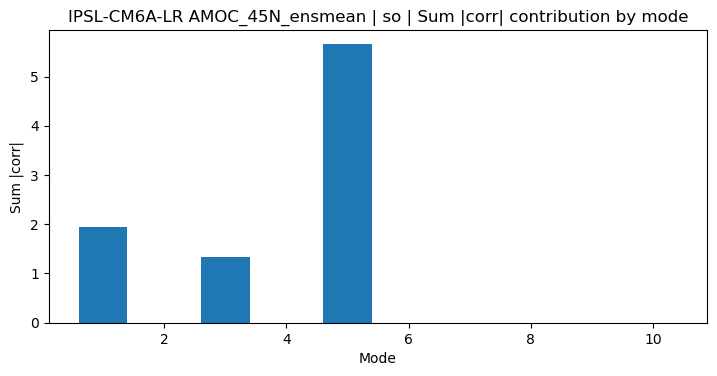

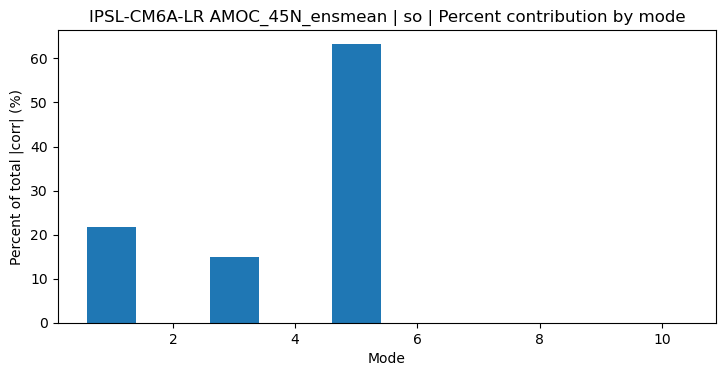

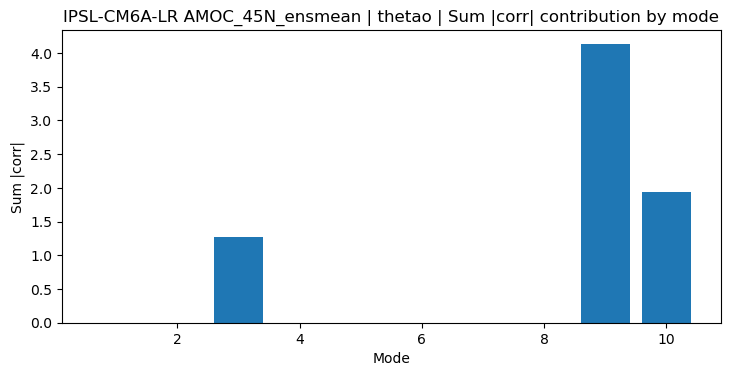

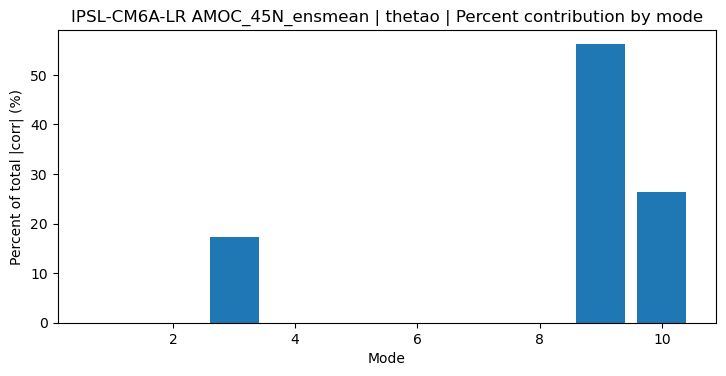

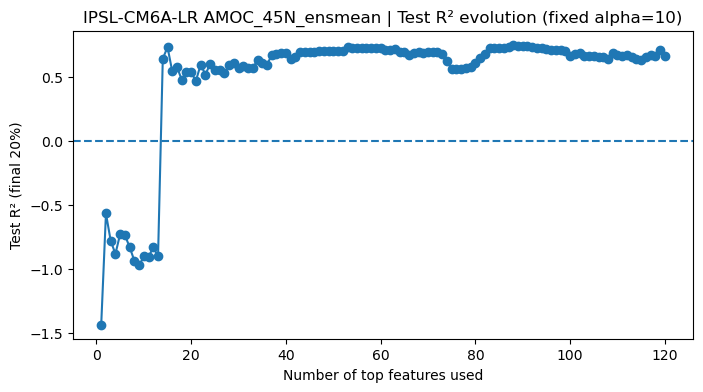

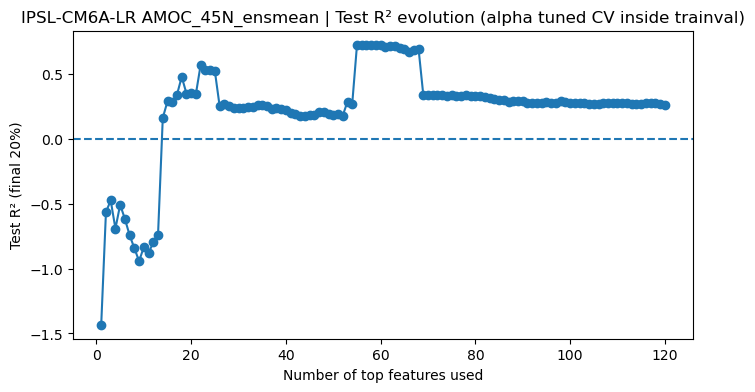

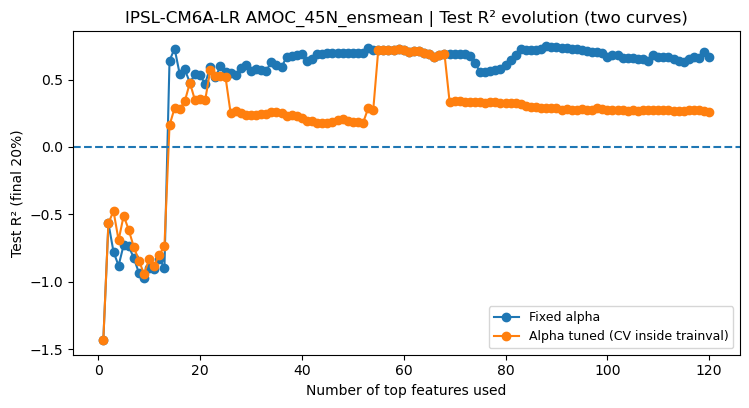

/tmp/ipykernel_1247148/3281200600.py:635: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


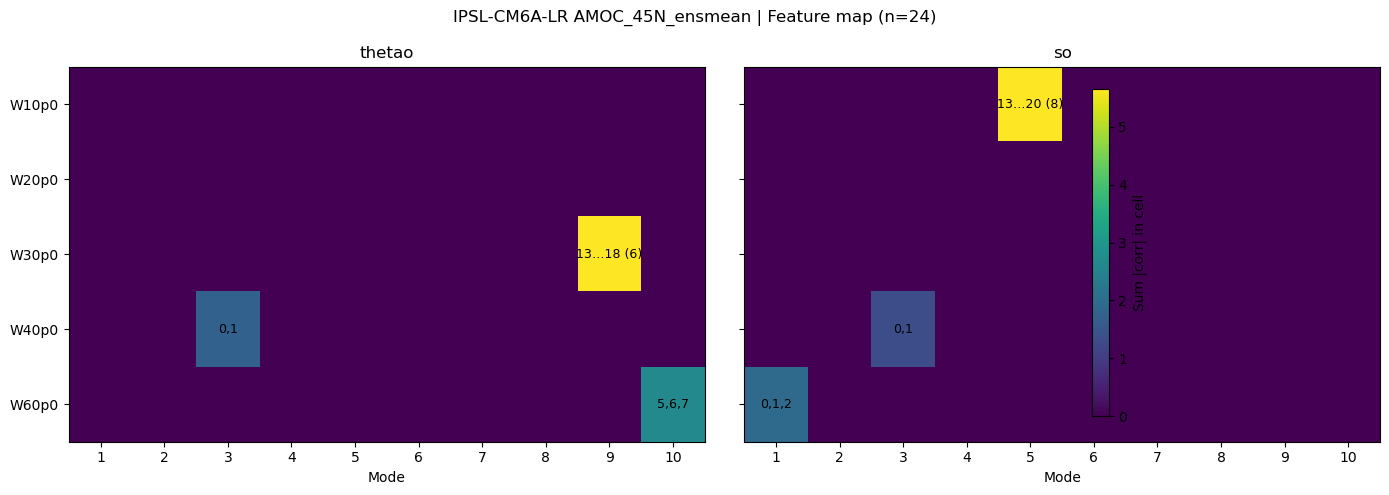


✅ All thesis figures generated in: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/R2_0.810_N15_W1/


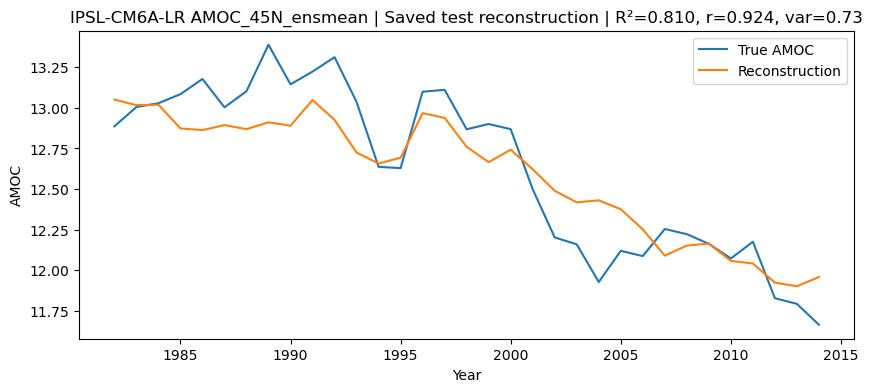

In [25]:
# ============================================================
# RUN ALL FIGURES
# ============================================================

# 1) EOF maps + PCs
plot_selected_eofs_and_pcs_oldstyle(
    feats=feats,
    outdir=os.path.join(OUTDIR, "01_EOF_PC"),
    max_panels=MAX_EOF_PANELS
)


# 2) Contribution histograms
df_sel = plot_feature_contribution_histograms(
    df_rank=df_rank,
    feats=feats,
    outdir=os.path.join(OUTDIR, "02_HIST"),
    title_prefix=f"{MODEL} {TARGET} | "
)

# 3) R² evolutions (two curves) + overlay
df_rank_r2 = df_rank.head(min(R2_EVOL_MAX_RANKED, len(df_rank))).copy()

df_fixed = r2_evolution_fixed_alpha(
    df_rank=df_rank_r2,
    pc_np=pc_np,
    years=years,
    y_amoc=y_amoc,
    n_trainval=n_trainval,
    alpha_fixed=ALPHA_FIXED,
    outdir=os.path.join(OUTDIR, "03_R2")
)

df_cv = r2_evolution_alpha_tuned_cv(
    df_rank=df_rank_r2,
    pc_np=pc_np,
    years=years,
    y_amoc=y_amoc,
    n_trainval=n_trainval,
    alpha_grid=ALPHA_GRID,
    n_splits=N_SPLITS,
    embargo=EMBARGO,
    outdir=os.path.join(OUTDIR, "03_R2")
)

plot_r2_overlay(
    df_fixed=df_fixed,
    df_cv=df_cv,
    outdir=os.path.join(OUTDIR, "03_R2"),
    title=f"{MODEL} {TARGET} | Test R² evolution (two curves)"
)

# 4) Feature map table
plot_feature_map_table(
    feats=feats,
    df_rank=df_rank,
    outdir=os.path.join(OUTDIR, "04_FEATUREMAP"),
    shading="corr"   # or "count"
)

print("\n✅ All thesis figures generated in:", OUTDIR)

# 5) Saved BEST_RUN reconstruction (exact y_true vs y_pred from pipeline test block)
plot_saved_test_reconstruction(
    pred_csv=BEST_TEST_PRED_CSV,
    metrics_csv=BEST_TEST_METRICS_CSV,
    outdir=os.path.join(OUTDIR, "05_TEST_RECON")
)



===== R² JUMP FEATURES =====

Feature #2
ΔR² = 0.9943969226303735
Feature = ('thetao', 'W30p0', 8, 16)

Feature #14
ΔR² = 1.7831110792129574
Feature = ('so', 'W60p0', 0, 1)

Feature #24
ΔR² = 0.24167064601196897
Feature = ('thetao', 'W30p0', 8, 18)


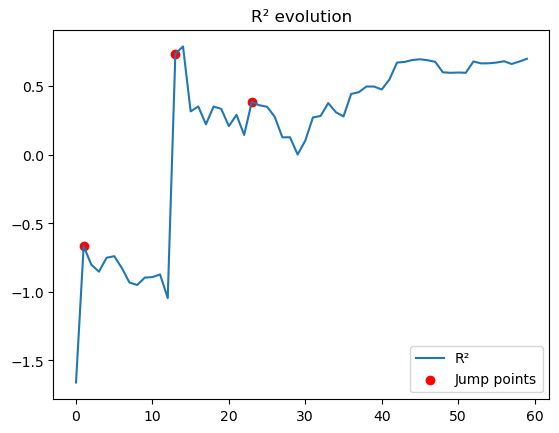

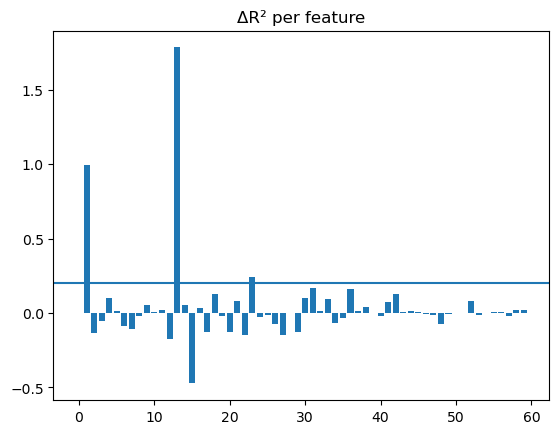


===== Correlation among jump features =====
('thetao', 'W30p0', 8, 16) <-> ('so', 'W60p0', 0, 1) corr = -0.4726750990646836
('thetao', 'W30p0', 8, 16) <-> ('thetao', 'W30p0', 8, 18) corr = 0.9999999999999999
('so', 'W60p0', 0, 1) <-> ('thetao', 'W30p0', 8, 18) corr = -0.4726750990646836


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# -------------------------------------------------
# USER INPUT
# -------------------------------------------------

RANK_FILE = "/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/R2_0.810_N15_W1_trainval_feature_ranking.csv"

MAX_FEATURES = 60
ALPHA = 1
JUMP_THRESHOLD = 0.2   # change if needed

# Requires these already loaded:
# pc_np : dict[(var,lon)] -> (T, n_modes)
# y_amoc : (T,)
# n_trainval
# years


# -------------------------------------------------
# Load ranking
# -------------------------------------------------

df_rank = pd.read_csv(RANK_FILE)
df_rank = df_rank.head(MAX_FEATURES).copy()

# convert to feature tuples
rank_feats = [
    (r.var, r.lon, int(r.mode)-1, int(r.lag))
    for r in df_rank.itertuples(index=False)
]


# -------------------------------------------------
# Helper to build X
# -------------------------------------------------

def build_X(feats, pc_np, y, idx):
    max_lag = max(f[3] for f in feats)
    used = idx[idx >= max_lag]

    X = np.empty((len(used), len(feats)))
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np[(var, lon)][t-lag, m0]

    return X, y[used]


# -------------------------------------------------
# Progressive reconstruction
# -------------------------------------------------

idx_trainval = np.arange(0, n_trainval)
idx_test     = np.arange(n_trainval, len(years))

r2_list = []
feat_labels = []

for k in range(1, len(rank_feats)+1):

    feats_k = rank_feats[:k]

    Xtv, Ytv = build_X(feats_k, pc_np, y_amoc, idx_trainval)
    Xte, Yte = build_X(feats_k, pc_np, y_amoc, idx_test)

    mdl = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
    mdl.fit(Xtv, Ytv)

    pred = mdl.predict(Xte)
    r2 = r2_score(Yte, pred)

    r2_list.append(r2)
    feat_labels.append(feats_k[-1])

r2_arr = np.array(r2_list)
delta_r2 = np.diff(np.insert(r2_arr, 0, r2_arr[0]))


# -------------------------------------------------
# Detect jump region
# -------------------------------------------------

jump_idx = np.where(delta_r2 > JUMP_THRESHOLD)[0]

print("\n===== R² JUMP FEATURES =====")
for i in jump_idx:
    print(f"\nFeature #{i+1}")
    print("ΔR² =", delta_r2[i])
    print("Feature =", feat_labels[i])


# -------------------------------------------------
# Plot R² + ΔR²
# -------------------------------------------------

plt.figure()
plt.plot(r2_arr, label="R²")
plt.scatter(jump_idx, r2_arr[jump_idx], color="red", label="Jump points")
plt.legend()
plt.title("R² evolution")
plt.show()

plt.figure()
plt.bar(np.arange(len(delta_r2)), delta_r2)
plt.axhline(JUMP_THRESHOLD)
plt.title("ΔR² per feature")
plt.show()


# -------------------------------------------------
# Correlation check between jump features
# -------------------------------------------------

def extract_feature_timeseries(feat):
    var, lon, m0, lag = feat
    series = pc_np[(var, lon)][:, m0]
    return series

print("\n===== Correlation among jump features =====")

jump_feats = [feat_labels[i] for i in jump_idx]

for i in range(len(jump_feats)):
    for j in range(i+1, len(jump_feats)):
        s1 = extract_feature_timeseries(jump_feats[i])
        s2 = extract_feature_timeseries(jump_feats[j])
        corr = np.corrcoef(s1, s2)[0,1]
        print(jump_feats[i], "<->", jump_feats[j], "corr =", corr)


Loading PCs...
Loading AMOC...
Aligning years...
✓ YEARS: 1850–2014 (T=165)
✓ TRAINVAL: 1850–1981 (T=132)
✓ TEST:     1982–2014 (T=33)

Computing R² evolution on TEST as features are added...

Spike points (k, ΔR², R², feature):
  k=  2  ΔR²= 0.994  R²=-0.667  thetao W30p0 EOF9 lag16
  k= 14  ΔR²= 1.783  R²= 0.738  so W60p0 EOF1 lag1
  k= 24  ΔR²= 0.242  R²= 0.387  thetao W30p0 EOF9 lag18
  k= 32  ΔR²= 0.169  R²= 0.273  thetao W20p0 EOF5 lag20
  k= 37  ΔR²= 0.164  R²= 0.444  so W10p0 EOF5 lag13

Total spike-features selected: 31


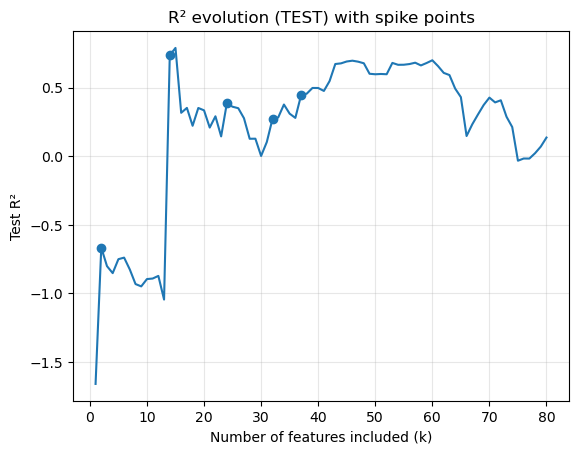

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_R2_evolution_spikes.png


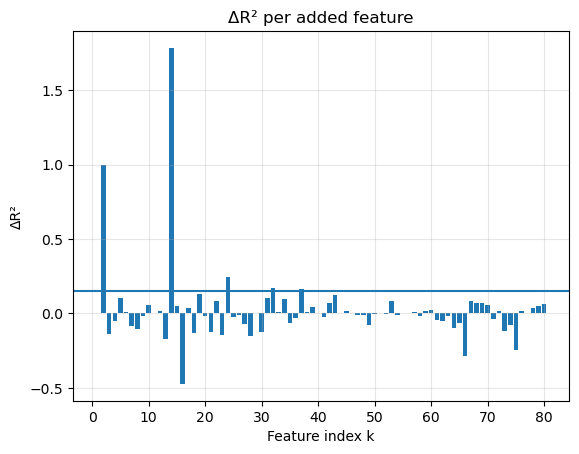

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_dR2_per_feature.png

Clustering spike features by predictor redundancy (trainval)...
Redundancy clusters (|corr|>=0.9):

Cluster 10 (n=6):
   thetao W10p0 EOF3 lag16
   thetao W10p0 EOF3 lag18
   thetao W10p0 EOF3 lag15
   thetao W10p0 EOF3 lag19
   thetao W20p0 EOF5 lag20
   thetao W10p0 EOF3 lag20

Cluster 14 (n=3):
   thetao W20p0 EOF3 lag19
   thetao W20p0 EOF3 lag18
   thetao W20p0 EOF3 lag17

Cluster 7 (n=2):
   so W10p0 EOF5 lag16
   so W10p0 EOF5 lag15

Cluster 9 (n=2):
   so W10p0 EOF5 lag18
   so W10p0 EOF5 lag19

Cluster 15 (n=2):
   thetao W40p0 EOF3 lag0
   thetao W60p0 EOF2 lag0

Cluster 1 (n=2):
   so W60p0 EOF1 lag1
   so W60p0 EOF1 lag2

Cluster 13 (n=2):
   thetao W30p0 EOF9 lag12
   thetao W30p0 EOF9 lag11

Cluster 18 (n=1):
   thetao W30p0 EOF9 lag16

Cluster 16 (n=1):
   thetao W30p0 EOF9 lag15

Cluster 17 (n=

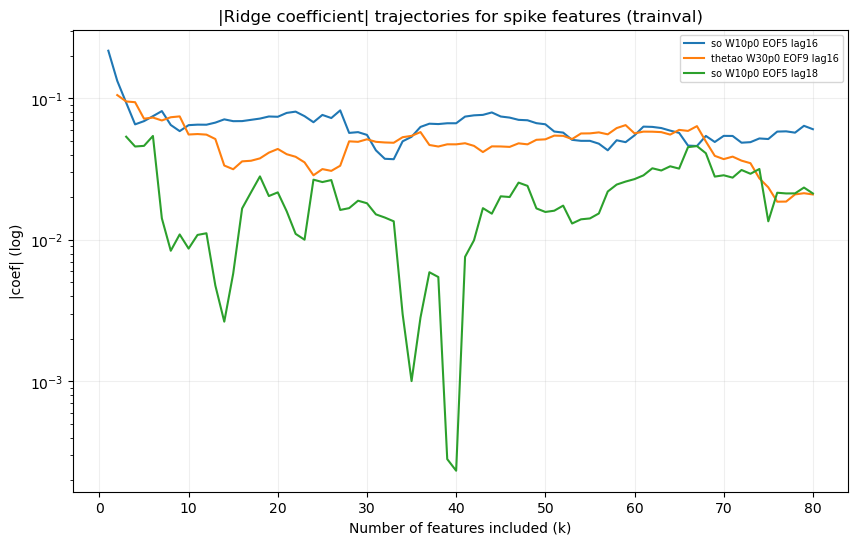

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_spike_coef_trajectories.png

Computing spatial similarity among spike EOF maps...
Spatial clusters (|pattern corr|>=0.85):

Cluster 1 (n=6):
  thetao W30p0 EOF9 lag16
  thetao W30p0 EOF9 lag15
  thetao W30p0 EOF9 lag14
  thetao W30p0 EOF9 lag18
  thetao W30p0 EOF9 lag12
  thetao W30p0 EOF9 lag11

Cluster 5 (n=6):
  thetao W10p0 EOF3 lag16
  thetao W10p0 EOF3 lag18
  thetao W10p0 EOF3 lag15
  thetao W10p0 EOF3 lag19
  thetao W20p0 EOF5 lag20
  thetao W10p0 EOF3 lag20

Cluster 9 (n=5):
  so W10p0 EOF5 lag16
  so W10p0 EOF5 lag18
  so W10p0 EOF5 lag15
  so W10p0 EOF5 lag19
  so W10p0 EOF5 lag13

Cluster 10 (n=3):
  thetao W60p0 EOF10 lag6
  thetao W60p0 EOF10 lag7
  thetao W60p0 EOF10 lag1

Cluster 7 (n=3):
  thetao W20p0 EOF3 lag19
  thetao W20p0 EOF3 lag18
  thetao W20p0 EOF3 lag17

Cluster 2 (n=2):
  so W60p0 EOF1 lag1
  so W60p0 

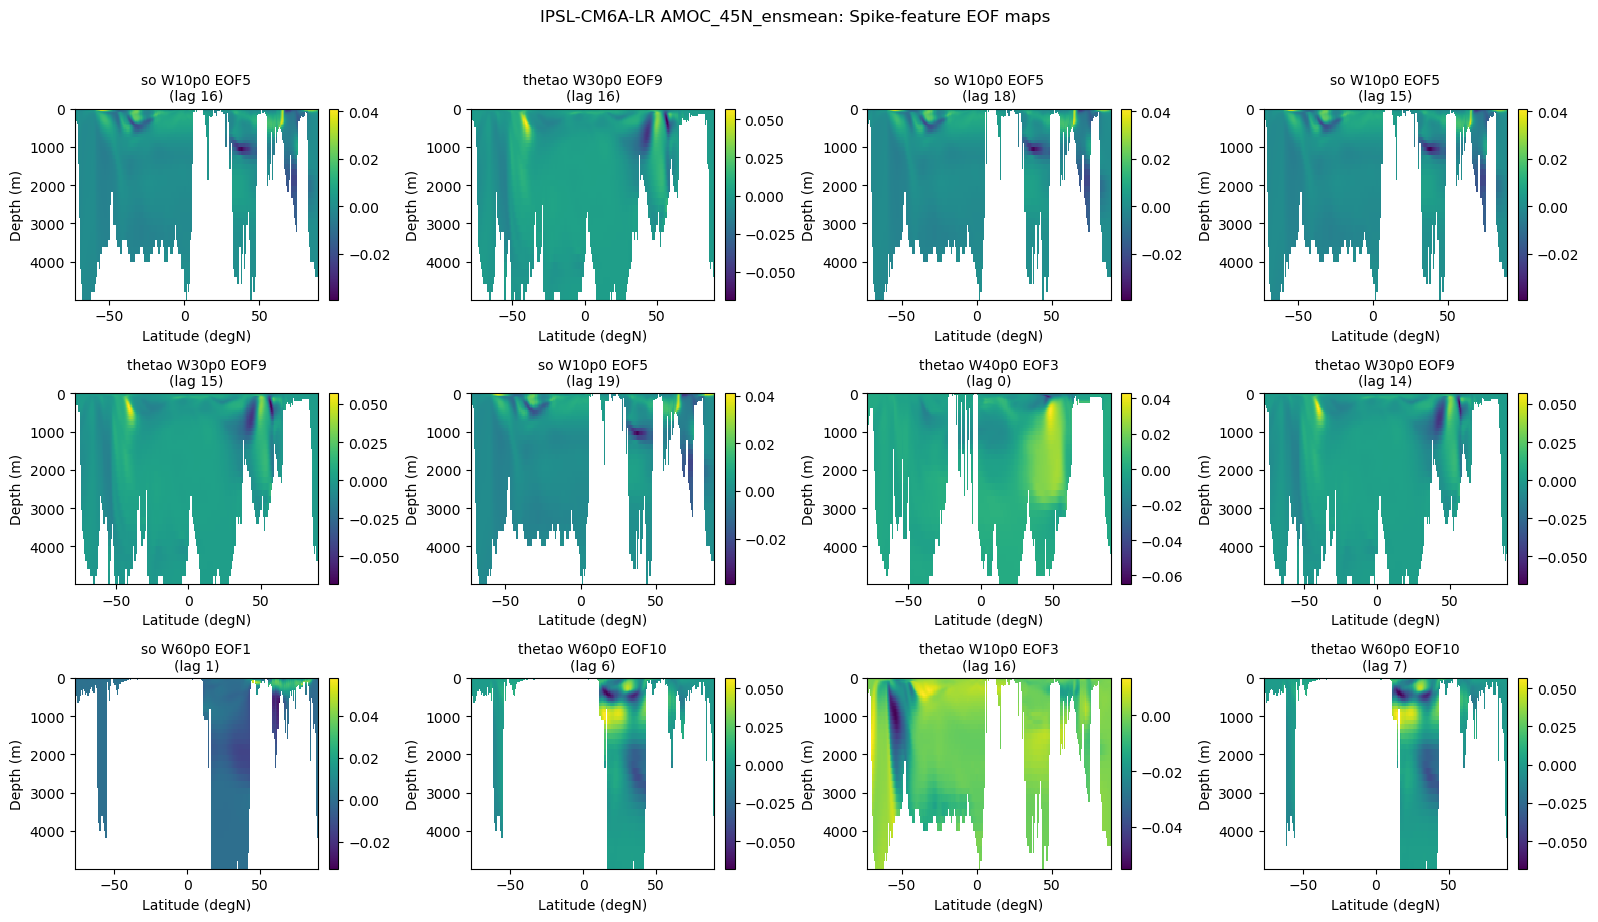

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_SPIKE_EOF_maps.png

================ RESULTS ================
Test R² baseline (top-K where K=MAXK): 0.136623465896612
Test R² spike-only (all spike feats): 0.5988714642878383
Test R² spike-only (1 per redundancy cluster): 0.7652243536226451
Test R² spike-only (1 per spatial cluster): 0.7197671636555052

Redundancy reps:
  so W10p0 EOF5 lag16
  thetao W30p0 EOF9 lag16
  so W10p0 EOF5 lag18
  thetao W30p0 EOF9 lag15
  thetao W40p0 EOF3 lag0
  thetao W30p0 EOF9 lag14
  so W60p0 EOF1 lag1
  thetao W60p0 EOF10 lag6
  thetao W10p0 EOF3 lag16
  thetao W60p0 EOF10 lag7
  so W40p0 EOF3 lag2
  thetao W30p0 EOF9 lag18
  thetao W30p0 EOF9 lag12
  thetao W20p0 EOF3 lag19
  so W20p0 EOF10 lag16
  so W20p0 EOF10 lag18
  thetao W60p0 EOF10 lag1
  so W40p0 EOF3 lag1
  so W10p0 EOF5 lag13

Spatial reps:
  so W10p0 EOF5 lag16
  thetao W30p0 EOF9 la

In [3]:
# ============================================================
# SPIKE FEATURE DIAGNOSTICS — AMOC reconstruction
# ------------------------------------------------------------
# What this script does (copy-paste ready):
#  0) Loads your trainval feature ranking CSV
#  1) Builds R² evolution on TEST as features are added
#  2) Detects "spike" features via ΔR² threshold + neighborhood
#  3) Clusters spike features by:
#       A) predictor redundancy (|corr| of predictor series, trainval)
#       B) spatial EOF-pattern similarity (|pattern corr| on common lat-lev grid)
#  4) Ridge coefficient trajectories for spike features (trainval fit)
#  5) Plots spike EOF maps using YOUR plot helpers
#  6) Tests recon skill using:
#       - all spike features
#       - one per redundancy cluster
#       - one per spatial cluster
#
# Requirements:
#   - You have the helper functions load_pc() and load_amoc() available
#     (from your pipeline script). If not, paste them above.
#   - You have numpy, pandas, xarray, matplotlib, sklearn, scipy installed.
#
# IMPORTANT:
#   - Update paths/CONFIG below if your lon tags or dirs differ.
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# ============================================================
# CONFIG — EDIT THESE
# ============================================================

MODEL   = "IPSL-CM6A-LR"
TARGET  = "AMOC_45N_ensmean"
MODE    = "ensmean"  # "ensmean" or "member" (this script assumes ensmean)
MEMBER_ID = None     # only if MODE="member"

# Data locations
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Ranking CSV (trainval ranking)
RANK_FILE = "/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/R2_0.810_N15_W1_trainval_feature_ranking.csv"

# Which PC sets exist on disk (must match your EOF files)
VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

# Time limits + split
YEAR_START = 1850
YEAR_END   = 2014
TEST_FRAC  = 0.2

# Diagnostics parameters
ALPHA_FOR_DIAG = 1.0
MAXK = 80                # how far down the ranking to analyze
SPIKE_D_R2 = 0.15         # ΔR² threshold for spike detection
SPIKE_WINDOW = 3          # include ± this many features around each spike
REDUND_CORR_THR = 0.90    # redundancy clustering threshold (predictor corr)
SPATIAL_CORR_THR = 0.85   # spatial clustering threshold (pattern corr)

# Spatial interpolation grid for pattern comparison
COMMON_NLAT = 180
COMMON_NLEV = 120

# Output directory for figures
OUTDIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/_SPIKE_DIAGNOSTICS"
os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# YOUR PLOT HELPERS — paste from your script (REUSED)
# ============================================================

def plot_latdepth_eof(ax, lat, lev, eof, title=""):
    """
    lat: 1D latitude (nlat,)
    lev: 1D depth (nlev,) (usually meters)
    eof: 2D (nlev, nlat) or (nlat, nlev) -> we handle both
    """
    eof = np.asarray(eof)

    # make sure eof is (lev, lat)
    if eof.shape == (len(lat), len(lev)):
        eof = eof.T
    if eof.shape != (len(lev), len(lat)):
        raise ValueError(f"EOF shape {eof.shape} does not match (lev,lat)=({len(lev)},{len(lat)})")

    m = ax.pcolormesh(lat, lev, eof, shading="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Latitude (degN)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()  # ocean depth downwards
    plt.colorbar(m, ax=ax, fraction=0.046, pad=0.04)

def load_latdepth_grid(ds):
    """
    Try common coord names for lat-depth sections.
    Returns lat (1D), lev (1D).
    """
    # latitude
    if "lat" in ds:
        lat = ds["lat"].values
    elif "latitude" in ds:
        lat = ds["latitude"].values
    elif "y" in ds and "nav_lat" in ds.coords:
        lat = ds["nav_lat"].values
    else:
        for name in ds.coords:
            if "lat" in name.lower():
                lat = ds[name].values
                break
        else:
            raise KeyError("Could not find latitude coordinate in dataset")

    # depth
    if "lev" in ds:
        lev = ds["lev"].values
    elif "depth" in ds:
        lev = ds["depth"].values
    elif "z" in ds:
        lev = ds["z"].values
    else:
        for name in ds.coords:
            if "lev" in name.lower() or "depth" in name.lower():
                lev = ds[name].values
                break
        else:
            raise KeyError("Could not find depth coordinate in dataset")

    lat = np.asarray(lat).astype(float)
    lev = np.asarray(lev).astype(float)
    if lat.ndim > 1:
        lat = lat[:, 0]
    if lev.ndim > 1:
        lev = lev[:, 0]
    lat = lat.squeeze()
    lev = lev.squeeze()
    return lat, lev


# ============================================================
# REQUIRED HELPERS (from your pipeline) — only if not defined
# ============================================================
# If you already have these in your notebook, you can delete this block.

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.data_vars:
        raise KeyError(f"Target '{target}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    dsA.close()
    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year


# ============================================================
# Build aligned pc_np, y_amoc, years, n_trainval
# ============================================================

print("Loading PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(
            EOF_DIR, var, lon, N_MODES,
            member_mode=(MODE == "member"),
            member_id=MEMBER_ID
        )

print("Loading AMOC...")
am = load_amoc(AMOC_FILE, TARGET, member_mode=(MODE == "member"), member_id=MEMBER_ID)

print("Aligning years...")
common_years = am["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()
common_years = common_years[(common_years >= YEAR_START) & (common_years <= YEAR_END)]

years = common_years
y_amoc = am.sel(year=years).values.astype(float).squeeze()
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

T = len(years)
n_test = int(np.ceil(TEST_FRAC * T))
n_trainval = T - n_test
idx_trainval = np.arange(0, n_trainval, dtype=int)
idx_test     = np.arange(n_trainval, T, dtype=int)

print(f"✓ YEARS: {years[0]}–{years[-1]} (T={T})")
print(f"✓ TRAINVAL: {years[0]}–{years[n_trainval-1]} (T={n_trainval})")
print(f"✓ TEST:     {years[n_trainval]}–{years[-1]} (T={len(idx_test)})")


# ============================================================
# Load ranking -> rank_feats list
# ============================================================

df_rank = pd.read_csv(RANK_FILE).copy()
df_rank = df_rank.head(min(MAXK, len(df_rank))).copy()

rank_feats = [(r.var, r.lon, int(r.mode)-1, int(r.lag)) for r in df_rank.itertuples(index=False)]

def feat_str(f):
    var, lon, m0, lag = f
    return f"{var} {lon} EOF{m0+1} lag{lag}"


# ============================================================
# Build X/Y from features (same as your build_XY logic)
# ============================================================

def build_XY_from_feats(pc_np, y, feats, idx):
    idx = np.asarray(idx, dtype=int)
    if len(feats) == 0:
        return np.empty((0, 0)), np.empty((0,)), np.array([], dtype=int), 0

    max_lag = max(lag for (_, _, _, lag) in feats)
    used = idx[idx >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np[(var, lon)][t - lag, int(m0)]
    Y = y[used]
    return X, Y, used, int(max_lag)

def fit_predict_r2(feats, alpha, idx_trainval, idx_test):
    Xtv, Ytv, _, _ = build_XY_from_feats(pc_np, y_amoc, feats, idx_trainval)
    Xte, Yte, _, _ = build_XY_from_feats(pc_np, y_amoc, feats, idx_test)
    if len(Ytv) < 20 or len(Yte) < 10:
        return np.nan
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(Xtv, Ytv)
    pred = mdl.predict(Xte)
    return float(r2_score(Yte, pred))

def fit_ridge_get_coefs(feats, alpha, idx_trainval):
    Xtv, Ytv, used, _ = build_XY_from_feats(pc_np, y_amoc, feats, idx_trainval)
    if len(Ytv) < 30:
        return None
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(Xtv, Ytv)
    coefs = mdl.named_steps["ridge"].coef_.copy()
    return coefs


# ============================================================
# 1) R² evolution + spike detection
# ============================================================

print("\nComputing R² evolution on TEST as features are added...")
r2_curve = []
for k in range(1, len(rank_feats) + 1):
    r2_curve.append(fit_predict_r2(rank_feats[:k], ALPHA_FOR_DIAG, idx_trainval, idx_test))
r2_curve = np.array(r2_curve, float)

d_r2 = np.diff(np.r_[r2_curve[0], r2_curve])
spike_idx = np.where(d_r2 >= SPIKE_D_R2)[0]

print("\nSpike points (k, ΔR², R², feature):")
for i in spike_idx:
    print(f"  k={i+1:3d}  ΔR²={d_r2[i]: .3f}  R²={r2_curve[i]: .3f}  {feat_str(rank_feats[i])}")

# Expand spike set with neighborhood
spike_set = set()
for i in spike_idx:
    for j in range(max(0, i - SPIKE_WINDOW), min(len(rank_feats), i + SPIKE_WINDOW + 1)):
        spike_set.add(j)

spike_feats = [rank_feats[i] for i in sorted(spike_set)]
print("\nTotal spike-features selected:", len(spike_feats))

# Plot R² and ΔR²
plt.figure()
plt.plot(np.arange(1, len(r2_curve) + 1), r2_curve)
plt.scatter(spike_idx + 1, r2_curve[spike_idx], marker="o")
plt.title("R² evolution (TEST) with spike points")
plt.xlabel("Number of features included (k)")
plt.ylabel("Test R²")
plt.grid(True, alpha=0.3)
f1 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_R2_evolution_spikes.png")
plt.savefig(f1, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", f1)

plt.figure()
plt.bar(np.arange(1, len(d_r2) + 1), d_r2)
plt.axhline(SPIKE_D_R2)
plt.title("ΔR² per added feature")
plt.xlabel("Feature index k")
plt.ylabel("ΔR²")
plt.grid(True, alpha=0.3)
f2 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_dR2_per_feature.png")
plt.savefig(f2, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", f2)


# ============================================================
# 2) Feature redundancy clustering (predictor series corr on trainval)
# ============================================================

def predictor_series(feat, idx_base):
    var, lon, m0, lag = feat
    idx_base = np.asarray(idx_base, int)
    idx_use = idx_base[idx_base >= lag]
    x = pc_np[(var, lon)][idx_use - lag, m0]
    return x, idx_use

def corr_matrix_feats(feats, idx_base):
    valid_sets = []
    series_list = []
    for f in feats:
        x, idx_use = predictor_series(f, idx_base)
        valid_sets.append(set(idx_use.tolist()))
        series_list.append((x, idx_use))

    common_idx = sorted(set.intersection(*valid_sets))
    if len(common_idx) < 30:
        raise RuntimeError(f"Too few shared points across feats: {len(common_idx)}")

    common_idx = np.array(common_idx, int)
    X = np.zeros((len(common_idx), len(feats)), float)

    for j, (x, idx_use) in enumerate(series_list):
        mapper = dict(zip(idx_use.tolist(), x.tolist()))
        X[:, j] = np.array([mapper[t] for t in common_idx], float)

    C = np.corrcoef(X, rowvar=False)
    return C

def cluster_by_abs_corr(feats, idx_base, corr_threshold=0.90):
    C = corr_matrix_feats(feats, idx_base)
    D = 1.0 - np.abs(C)
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method="average")
    labels = fcluster(Z, t=(1.0 - corr_threshold), criterion="distance")
    clusters = {}
    for f, lab in zip(feats, labels):
        clusters.setdefault(lab, []).append(f)
    return C, clusters

print("\nClustering spike features by predictor redundancy (trainval)...")
C_red, clusters_red = cluster_by_abs_corr(spike_feats, idx_trainval, corr_threshold=REDUND_CORR_THR)

print(f"Redundancy clusters (|corr|>={REDUND_CORR_THR}):")
for lab, members in sorted(clusters_red.items(), key=lambda kv: -len(kv[1])):
    print(f"\nCluster {lab} (n={len(members)}):")
    for f in members:
        print("  ", feat_str(f))

rank_pos = {f: i for i, f in enumerate(rank_feats)}
reps_red = []
for lab, members in clusters_red.items():
    rep = sorted(members, key=lambda f: rank_pos.get(f, 10**9))[0]
    reps_red.append(rep)
reps_red = sorted(reps_red, key=lambda f: rank_pos.get(f, 10**9))


# ============================================================
# 3) Ridge coefficient trajectories for spike features
# ============================================================

print("\nComputing ridge coefficient trajectories (trainval fit)...")
K_track = len(rank_feats)
spike_set_only = set(spike_feats)

coef_traj = {f: [] for f in spike_feats}
k_values = []

for k in range(1, K_track + 1):
    feats_k = rank_feats[:k]
    coefs = fit_ridge_get_coefs(feats_k, ALPHA_FOR_DIAG, idx_trainval)
    if coefs is None:
        continue

    pos = {f: i for i, f in enumerate(feats_k)}
    for f in spike_feats:
        coef_traj[f].append(coefs[pos[f]] if f in pos else np.nan)

    k_values.append(k)

k_values = np.array(k_values, int)

# ---- SELECT HOW MANY SPIKES TO SHOW ----
N_SPIKES_TO_PLOT = 3
spikes_to_plot = spike_feats[:N_SPIKES_TO_PLOT]

plt.figure(figsize=(10, 6))
for f in spikes_to_plot:
    plt.plot(k_values, np.abs(np.array(coef_traj[f], float)), label=feat_str(f))

plt.yscale("log")
plt.title("|Ridge coefficient| trajectories for spike features (trainval)")
plt.xlabel("Number of features included (k)")
plt.ylabel("|coef| (log)")
plt.legend(fontsize=7)
plt.grid(True, alpha=0.2)

f3 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_spike_coef_trajectories.png")
plt.savefig(f3, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", f3)



# ============================================================
# 4) Spatial pattern comparison + clustering (EOF maps)
#    Uses YOUR file loading approach + interp to common grid
# ============================================================

def load_eof_map_latdepth(eof_file, mode0):
    ds = xr.open_dataset(eof_file)
    lat, lev = load_latdepth_grid(ds)
    if "EOF" not in ds.data_vars:
        raise KeyError(f"'EOF' not in {eof_file}. Vars={list(ds.data_vars)}")
    EOF = ds["EOF"].isel(mode=int(mode0)).values
    ds.close()
    return np.asarray(lat, float), np.asarray(lev, float), np.asarray(EOF, float)

def eof_to_da_on_grid(lat, lev, eof):
    eof = np.asarray(eof)
    if eof.shape == (len(lat), len(lev)):
        eof = eof.T
    if eof.shape != (len(lev), len(lat)):
        raise ValueError(f"EOF shape {eof.shape} does not match (lev,lat)=({len(lev)},{len(lat)})")
    return xr.DataArray(eof, coords={"lev": lev, "lat": lat}, dims=("lev", "lat"))

def build_common_grid_overlap(raw_maps, nlat=180, nlev=120):
    lat_mins = [np.nanmin(lat) for lat, lev, eof in raw_maps]
    lat_maxs = [np.nanmax(lat) for lat, lev, eof in raw_maps]
    lev_mins = [np.nanmin(lev) for lat, lev, eof in raw_maps]
    lev_maxs = [np.nanmax(lev) for lat, lev, eof in raw_maps]

    lat_lo, lat_hi = max(lat_mins), min(lat_maxs)
    lev_lo, lev_hi = max(lev_mins), min(lev_maxs)

    if lat_lo >= lat_hi or lev_lo >= lev_hi:
        raise RuntimeError("No common overlap in (lat,lev) across maps. Use union grid if needed.")

    lat_grid = np.linspace(lat_lo, lat_hi, int(nlat))
    lev_grid = np.linspace(lev_lo, lev_hi, int(nlev))
    return lat_grid, lev_grid

def interp_map_to_common(lat, lev, eof, lat_grid, lev_grid):
    da = eof_to_da_on_grid(lat, lev, eof)
    dai = da.interp(lat=lat_grid, lev=lev_grid, kwargs={"fill_value": np.nan})
    return dai.values

def pattern_corr_2d(A, B):
    A = np.asarray(A).ravel()
    B = np.asarray(B).ravel()
    m = np.isfinite(A) & np.isfinite(B)
    if m.sum() < 50:
        return np.nan
    a = A[m] - A[m].mean()
    b = B[m] - B[m].mean()
    denom = np.sqrt(np.sum(a*a) * np.sum(b*b))
    if denom == 0:
        return np.nan
    return float(np.sum(a*b) / denom)

print("\nComputing spatial similarity among spike EOF maps...")
raw_maps = []
keys_spatial = []
for (var, lon, m0, lag) in spike_feats:
    eof_file = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    lat, lev, eof = load_eof_map_latdepth(eof_file, m0)
    raw_maps.append((lat, lev, eof))
    keys_spatial.append((var, lon, m0, lag))

lat_grid, lev_grid = build_common_grid_overlap(raw_maps, nlat=COMMON_NLAT, nlev=COMMON_NLEV)
mats = [interp_map_to_common(lat, lev, eof, lat_grid, lev_grid) for (lat, lev, eof) in raw_maps]
mats = np.array(mats)  # (K, nlev, nlat)

K = len(mats)
P = np.full((K, K), np.nan, float)
for i in range(K):
    for j in range(K):
        P[i, j] = pattern_corr_2d(mats[i], mats[j])

# cluster by |pattern corr|
D = 1.0 - np.abs(P)
np.fill_diagonal(D, 0.0)
Z = linkage(squareform(D, checks=False), method="average")
labels = fcluster(Z, t=(1.0 - SPATIAL_CORR_THR), criterion="distance")

clusters_spatial = {}
for key, lab in zip(keys_spatial, labels):
    clusters_spatial.setdefault(lab, []).append(key)

print(f"Spatial clusters (|pattern corr|>={SPATIAL_CORR_THR}):")
for lab, members in sorted(clusters_spatial.items(), key=lambda kv: -len(kv[1])):
    print(f"\nCluster {lab} (n={len(members)}):")
    for (var, lon, m0, lag) in members:
        print(f"  {var} {lon} EOF{m0+1} lag{lag}")

# representatives (earliest in rank)
reps_spatial = []
for lab, members in clusters_spatial.items():
    rep = sorted(members, key=lambda f: rank_pos.get(f, 10**9))[0]
    reps_spatial.append(rep)
reps_spatial = sorted(reps_spatial, key=lambda f: rank_pos.get(f, 10**9))


# ============================================================
# 5) Plot spike EOF maps (YOUR plotting approach)
# ============================================================

def plot_spike_eof_maps(spike_feats, EOF_DIR, OUTDIR, max_plots=12):
    feats = spike_feats[:max_plots]
    ncols = 4
    nrows = int(np.ceil(len(feats) / ncols))
    plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, (var, lon, m0, lag) in enumerate(feats):
        ax = plt.subplot(nrows, ncols, i + 1)
        eof_file = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")

        if not os.path.exists(eof_file):
            ax.set_title(f"MISSING\n{var} {lon} EOF{m0+1}", fontsize=9)
            ax.axis("off")
            continue

        ds = xr.open_dataset(eof_file)
        EOF = ds["EOF"].isel(mode=int(m0)).values
        lat, lev = load_latdepth_grid(ds)
        ds.close()

        plot_latdepth_eof(
            ax, lat, lev, EOF,
            title=f"{var} {lon} EOF{m0+1}\n(lag {lag})"
        )

    plt.suptitle(f"{MODEL} {TARGET}: Spike-feature EOF maps", y=1.02)
    plt.tight_layout()
    fout = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_SPIKE_EOF_maps.png")
    plt.savefig(fout, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fout)

plot_spike_eof_maps(spike_feats, EOF_DIR, OUTDIR, max_plots=12)


# ============================================================
# 6) Spike-only reconstructions
# ============================================================

r2_spike_only = fit_predict_r2(spike_feats, ALPHA_FOR_DIAG, idx_trainval, idx_test)
r2_spike_red  = fit_predict_r2(reps_red,   ALPHA_FOR_DIAG, idx_trainval, idx_test)
r2_spike_spat = fit_predict_r2(reps_spatial, ALPHA_FOR_DIAG, idx_trainval, idx_test)

print("\n================ RESULTS ================")
print("Test R² baseline (top-K where K=MAXK):", fit_predict_r2(rank_feats, ALPHA_FOR_DIAG, idx_trainval, idx_test))
print("Test R² spike-only (all spike feats):", r2_spike_only)
print("Test R² spike-only (1 per redundancy cluster):", r2_spike_red)
print("Test R² spike-only (1 per spatial cluster):", r2_spike_spat)

print("\nRedundancy reps:")
for f in reps_red:
    print(" ", feat_str(f))

print("\nSpatial reps:")
for f in reps_spatial:
    print(" ", feat_str(f))



Spike-only (1 per redundancy cluster) model
alpha = 1.0
n_features_used = 19
max_lag_used = 19 years
TEST R² (recomputed) = 0.765224

Features used:


,var,lon,EOF_mode(1-based),mode0(0-based),lag_years
0,so,W10p0,5,4,13
1,so,W10p0,5,4,16
2,so,W10p0,5,4,18
3,so,W20p0,10,9,16
4,so,W20p0,10,9,18
5,so,W40p0,3,2,1
6,so,W40p0,3,2,2
7,so,W60p0,1,0,1
8,thetao,W10p0,3,2,16
9,thetao,W20p0,3,2,19


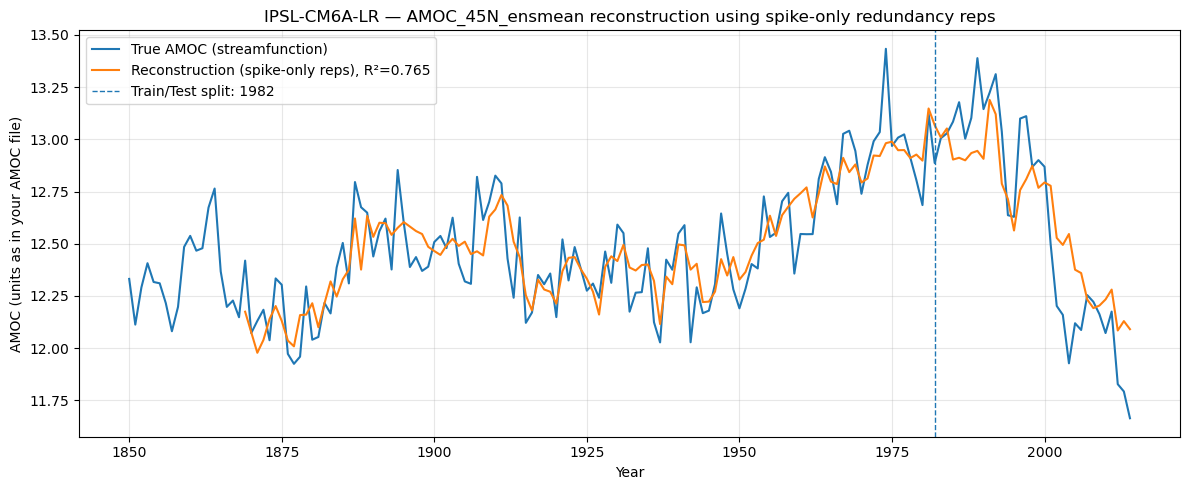

Saved plot: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_RECON_spike_only_redundancy_reps.png


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# USE THE EXACT FEATURE LIST FROM YOUR OUTPUT
# (Option A) If reps_red already exists, keep this:
# ============================================================
try:
    reps_red
except NameError:
    reps_red = [
        ("so","W10p0", 4,16),
        ("thetao","W30p0", 8,16),
        ("so","W10p0", 4,18),
        ("thetao","W30p0", 8,15),
        ("thetao","W40p0", 2,0),
        ("thetao","W30p0", 8,14),
        ("so","W60p0", 0,1),
        ("thetao","W60p0", 9,6),
        ("thetao","W10p0", 2,16),
        ("thetao","W60p0", 9,7),
        ("so","W40p0", 2,2),
        ("thetao","W30p0", 8,18),
        ("thetao","W30p0", 8,12),
        ("thetao","W20p0", 2,19),
        ("so","W20p0", 9,16),
        ("so","W20p0", 9,18),
        ("thetao","W60p0", 9,1),
        ("so","W40p0", 2,1),
        ("so","W10p0", 4,13),
    ]
# NOTE: mode0 is 0-based (EOF5 -> mode0=4), matching your script.

ALPHA_PLOT = 1.0  # must match ALPHA_FOR_DIAG you used for the reported R²

def feat_str(f):
    var, lon, m0, lag = f
    return f"{var} {lon} EOF{m0+1} lag{lag}"

# ============================================================
# Build train/test matrices and fit model
# ============================================================
Xtv, Ytv, used_tv, maxlag_tv = build_XY_from_feats(pc_np, y_amoc, reps_red, idx_trainval)
Xte, Yte, used_te, maxlag_te = build_XY_from_feats(pc_np, y_amoc, reps_red, idx_test)

mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA_PLOT)))
mdl.fit(Xtv, Ytv)

pred_tv = mdl.predict(Xtv)
pred_te = mdl.predict(Xte)

r2_te = float(r2_score(Yte, pred_te))

# ============================================================
# Make a combined (years-aligned) prediction series for plotting
# (NaNs for years where prediction isn't defined because of max lag)
# ============================================================
y_true_all = np.full(len(years), np.nan, float)
y_pred_all = np.full(len(years), np.nan, float)

# fill true AMOC for all years
y_true_all[:] = y_amoc

# fill predictions where defined
y_pred_all[used_tv] = pred_tv
y_pred_all[used_te] = pred_te

# ============================================================
# Print exact feature list used
# ============================================================
feat_table = pd.DataFrame(
    [{
        "var": v,
        "lon": l,
        "EOF_mode(1-based)": m0+1,
        "mode0(0-based)": m0,
        "lag_years": lag
    } for (v,l,m0,lag) in reps_red]
).sort_values(["var","lon","EOF_mode(1-based)","lag_years"]).reset_index(drop=True)

print("\n===============================================")
print("Spike-only (1 per redundancy cluster) model")
print("===============================================")
print(f"alpha = {ALPHA_PLOT}")
print(f"n_features_used = {len(reps_red)}")
print(f"max_lag_used = {max(lag for *_, lag in reps_red)} years")
print(f"TEST R² (recomputed) = {r2_te:.6f}")
print("\nFeatures used:")
display(feat_table)  # if in notebook; otherwise print(feat_table.to_string(index=False))

# ============================================================
# Plot: true AMOC vs reconstruction
# ============================================================
split_year = years[n_trainval]  # first test year

plt.figure(figsize=(12,5))
plt.plot(years, y_true_all, label="True AMOC (streamfunction)")
plt.plot(years, y_pred_all, label=f"Reconstruction (spike-only reps), R²={r2_te:.3f}")
plt.axvline(split_year, linestyle="--", linewidth=1, label=f"Train/Test split: {split_year}")
plt.title(f"{MODEL} — {TARGET} reconstruction using spike-only redundancy reps")
plt.xlabel("Year")
plt.ylabel("AMOC (units as in your AMOC file)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_png = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_RECON_spike_only_redundancy_reps.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", out_png)



3 SPIKE FEATURE MODEL
Test R² = 0.4288
Number of features = 3
Max lag = 3 years

so W60p0 EOF1 lag1
thetao W40p0 EOF3 lag0
so W30p0 EOF1 lag3


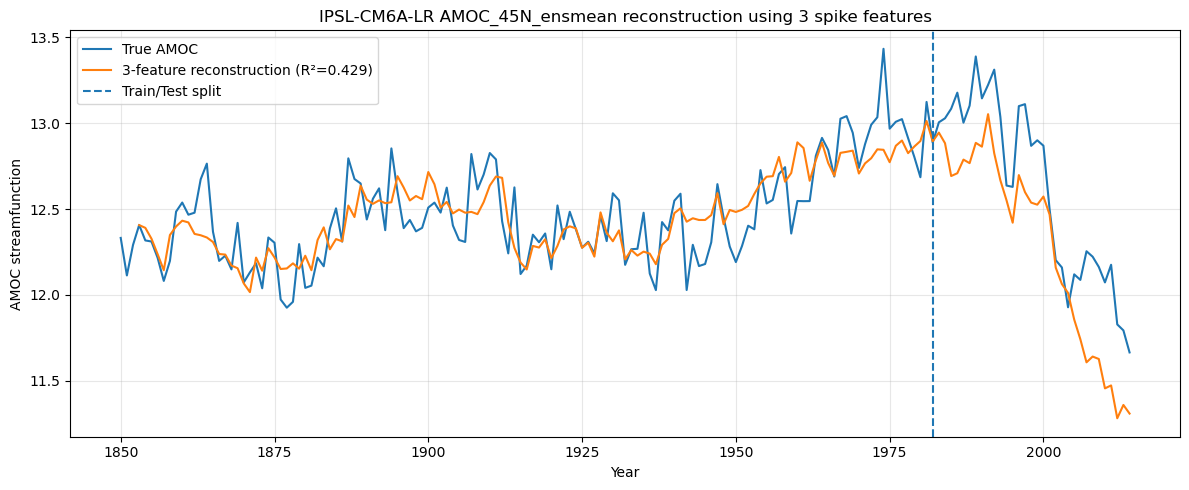

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/_SPIKE_DIAGNOSTICS/IPSL-CM6A-LR_AMOC_45N_ensmean_RECON_3_spike_features.png


In [11]:
# ============================================================
# 3-SPIKE FEATURE RECONSTRUCTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Define the THREE spike-trigger features
# ------------------------------------------------------------
spike2_feats = [
    ("so", "W60p0", 0, 1),
    ("thetao", "W40p0", 2, 0),
    ("so", "W30p0", 0, 3)    # EOF mode, lag
]

ALPHA_SPIKE3 = 1.0   # keep consistent with earlier diagnostics

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------
Xtv, Ytv, used_tv, maxlag_tv = build_XY_from_feats(pc_np, y_amoc, spike2_feats, idx_trainval)
Xte, Yte, used_te, maxlag_te = build_XY_from_feats(pc_np, y_amoc, spike2_feats, idx_test)


# ------------------------------------------------------------
# Fit model
# ------------------------------------------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA_SPIKE3))
mdl.fit(Xtv, Ytv)

pred_tv = mdl.predict(Xtv)
pred_te = mdl.predict(Xte)

r2_te = r2_score(Yte, pred_te)


# ------------------------------------------------------------
# Build full-length prediction series
# ------------------------------------------------------------
y_pred_all = np.full(len(years), np.nan)
y_pred_all[used_tv] = pred_tv
y_pred_all[used_te] = pred_te


# ------------------------------------------------------------
# Print feature summary
# ------------------------------------------------------------
print("\n==============================")
print("3 SPIKE FEATURE MODEL")
print("==============================")

print(f"Test R² = {r2_te:.4f}")
print(f"Number of features = {len(spike2_feats)}")
print(f"Max lag = {max(lag for *_, lag in spike2_feats)} years\n")

for f in spike2_feats:
    var, lon, m0, lag = f
    print(f"{var} {lon} EOF{m0+1} lag{lag}")


# ------------------------------------------------------------
# Plot reconstruction
# ------------------------------------------------------------
split_year = years[n_trainval]

plt.figure(figsize=(12,5))

plt.plot(years, y_amoc, label="True AMOC")
plt.plot(years, y_pred_all, label=f"3-feature reconstruction (R²={r2_te:.3f})")

plt.axvline(split_year, linestyle="--", label="Train/Test split")

plt.title(f"{MODEL} {TARGET} reconstruction using 3 spike features")
plt.xlabel("Year")
plt.ylabel("AMOC streamfunction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

outfile = os.path.join(
    OUTDIR,
    f"{MODEL}_{TARGET}_RECON_3_spike_features.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)
